# Resume–Job Matching with Text Embeddings
CS 4650 Final Project — Aniya Pauling, Huang Tian, Andre Koga, Kishan Patel

In [37]:
!pip install datasets -q

## 1. Data Loading & Preprocessing

We use the `0xnbk/resume-ats-score-v1-en` dataset from Hugging Face, which contains 6,374 resume–job description pairs. Each row stores a resume and a job description concatenated in a single `text` field separated by the token `SEP`. We parse each row to extract the resume and job description as separate fields, alongside the continuous ATS compatibility score (18.3–90.7) and a 3-class categorical label (`"No Fit"`, `"Potential Fit"`, `"Good Fit"`). The dataset is pre-split into 5,099 training rows and 1,275 validation rows.

In [38]:
from datasets import load_dataset
import pandas as pd

raw = load_dataset("0xnbk/resume-ats-score-v1-en")
print(raw)

DatasetDict({
    train: Dataset({
        features: ['text', 'ats_score', 'original_label'],
        num_rows: 5099
    })
    validation: Dataset({
        features: ['text', 'ats_score', 'original_label'],
        num_rows: 1275
    })
})


In [39]:
# Find the actual separator — search the full text
sample = raw["train"][0]
print("Keys:", list(sample.keys()))
print("ats_score:", sample["ats_score"])
print("original_label:", sample["original_label"])
print(f"Full text length: {len(sample['text'])} chars")
print()

# Print a window around the middle of the text to find the separator
text = sample["text"]
mid = len(text) // 2
print(f"--- chars 400-600 ---")
print(repr(text[400:600]))
print()
print(f"--- chars {mid-100}:{mid+100} ---")
print(repr(text[mid-100:mid+100]))
print()

# Search for any non-alphanumeric/punctuation patterns that look like a separator
import re
special = re.findall(r'[^\w\s.,!?;:\'\"-]{2,}', text)
print("Unusual token patterns found:", list(set(special))[:20])

Keys: ['text', 'ats_score', 'original_label']
ats_score: 80.6
original_label: Good Fit
Full text length: 5324 chars

--- chars 400-600 ---
'tware applicationsStrong understanding of structured programming techniques and Software Development life Cycle (SDLC) - Agile (SCRUM)Able to learn, understand, and apply new software programs easily.'

--- chars 2562:2762 ---
'such as trends, budget data, and maintenance cycles.Design and develop workflow, test plans, and business processes to ensure functionality, completeness, and quality.Work closely with other departmen'

Unusual token patterns found: []


In [ ]:
import re

def parse_row(row):
    # Use word boundary so "September" or "separate" don't trigger a false split
    parts = re.split(r'\bSEP\b', row["text"], maxsplit=1)
    resume = parts[0].strip()
    job_desc = parts[1].strip() if len(parts) > 1 else ""
    return {
        "resume": resume,
        "job_description": job_desc,
        "ats_score": row["ats_score"],
        "label": row["original_label"],
    }

train_df = pd.DataFrame([parse_row(r) for r in raw["train"]])
val_df   = pd.DataFrame([parse_row(r) for r in raw["validation"]])

print(f"Train: {len(train_df)} rows | Val: {len(val_df)} rows")
print(f"Empty job_descriptions — train: {(train_df['job_description'] == '').sum()}, val: {(val_df['job_description'] == '').sum()}")
train_df.head()

## 2. Exploratory Data Analysis

Before modeling, we examine the distribution of ATS scores and class labels in the training set, and measure the length (in words) of both resumes and job descriptions. This informs key modeling decisions — in particular, resumes average ~720 words while SBERT has a default maximum sequence length of 256 tokens, meaning longer resumes will be truncated. Job descriptions average ~378 words and are less affected by this limit.

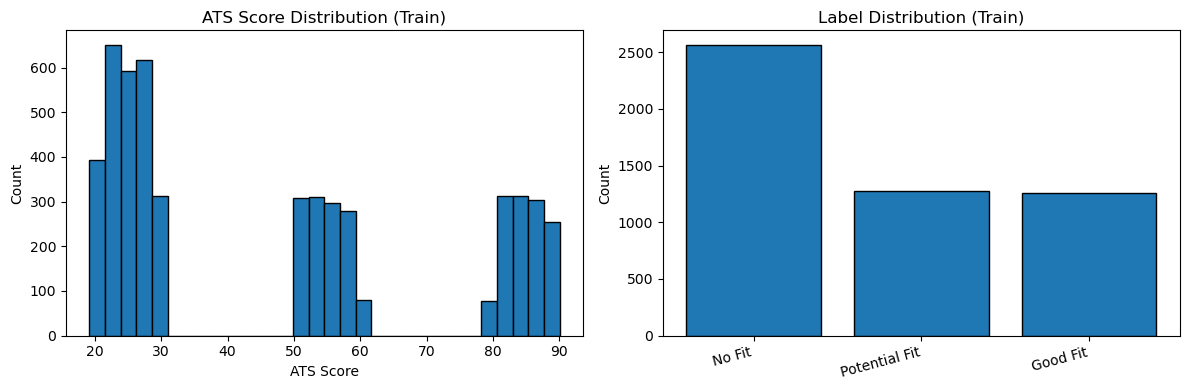

Label values: ['Good Fit' 'No Fit' 'Potential Fit']
         ats_score
count  5099.000000
mean     47.187452
std      24.970249
min      19.160000
25%      24.700000
50%      29.900000
75%      59.800000
max      90.050000


In [41]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ATS score distribution
axes[0].hist(train_df["ats_score"], bins=30, edgecolor="black")
axes[0].set_title("ATS Score Distribution (Train)")
axes[0].set_xlabel("ATS Score")
axes[0].set_ylabel("Count")

# Label distribution — labels may be strings or ints
if "label" in train_df.columns:
    counts = train_df["label"].value_counts()
    axes[1].bar(counts.index.astype(str), counts.values, edgecolor="black")
    axes[1].set_title("Label Distribution (Train)")
    axes[1].set_ylabel("Count")
    plt.setp(axes[1].get_xticklabels(), rotation=15, ha="right")

plt.tight_layout()
plt.show()

print("Label values:", train_df["label"].unique() if "label" in train_df.columns else "N/A")
print(train_df[["ats_score"]].describe())

In [42]:
# Check text lengths to understand input sizes for models
train_df["resume_len"]   = train_df["resume"].str.split().str.len()
train_df["job_desc_len"] = train_df["job_description"].str.split().str.len()

print("Resume word count:")
print(train_df["resume_len"].describe())
print()
print("Job description word count:")
print(train_df["job_desc_len"].describe())

Resume word count:
count    5099.000000
mean      720.099235
std       380.070373
min         4.000000
25%       509.000000
50%       634.000000
75%       829.000000
max      2057.000000
Name: resume_len, dtype: float64

Job description word count:
count    5099.000000
mean      378.293391
std       245.938642
min        11.000000
25%       172.000000
50%       329.000000
75%       540.000000
max      1662.000000
Name: job_desc_len, dtype: float64


In [43]:
# Verify no empty parses
empty_resumes  = (train_df["resume"] == "").sum()
empty_job_desc = (train_df["job_description"] == "").sum()
print(f"Empty resumes: {empty_resumes} | Empty job descriptions: {empty_job_desc}")

# Print one example pair
print("\n--- Sample resume (first 300 chars) ---")
print(train_df["resume"].iloc[0][:300])
print("\n--- Sample job description (first 300 chars) ---")
print(train_df["job_description"].iloc[0][:300])

label_val = train_df["label"].iloc[0] if "label" in train_df.columns else "N/A"
print(f"\nATS score: {train_df['ats_score'].iloc[0]} | Label: {label_val}")

Empty resumes: 0 | Empty job descriptions: 0

--- Sample resume (first 300 chars) ---
SummaryI am seeking a position wherein I may use my proven development, technical, and analytical skills while having the opportunity to continue my learning and diversify my experiences. Highlights17 years experience in Information TechnologyHeld a Secret security clearanceExpert in business proces

--- Sample job description (first 300 chars) ---
- Share resume to shan imrsoft.com Job Title JDE Business AnalystLocation REMOTE Mandatory Skills JDE World Homebuilder Job Description Extensive experience ( 10 years) in JDE World Homebuilder, Job Cost, and Procurement module functions functionality and associated business processes. (Primary)Hand

ATS score: 80.6 | Label: Good Fit
